In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

In [7]:
# We specifically parse the 'Date' column to handle time-series data
df = pd.read_csv('train.csv', parse_dates=['Date'])
# Filter for Store 1
store_data = df[df['Store'] == 1]

# Aggregate sales by Date (summing up all departments for that week)
ts_data = store_data.groupby('Date')['Weekly_Sales'].sum().reset_index()

# Set Date as the index (required for Time Series analysis)
ts_data.set_index('Date', inplace=True)

# Resample to ensure weekly frequency (Monday start)
ts_data = ts_data.asfreq('W-FRI')

print("Data Loaded and Preprocessed. First 5 rows:")
print(ts_data.head())

Data Loaded and Preprocessed. First 5 rows:
            Weekly_Sales
Date                    
2010-02-05    1643690.90
2010-02-12    1641957.44
2010-02-19    1611968.17
2010-02-26    1409727.59
2010-03-05    1554806.68


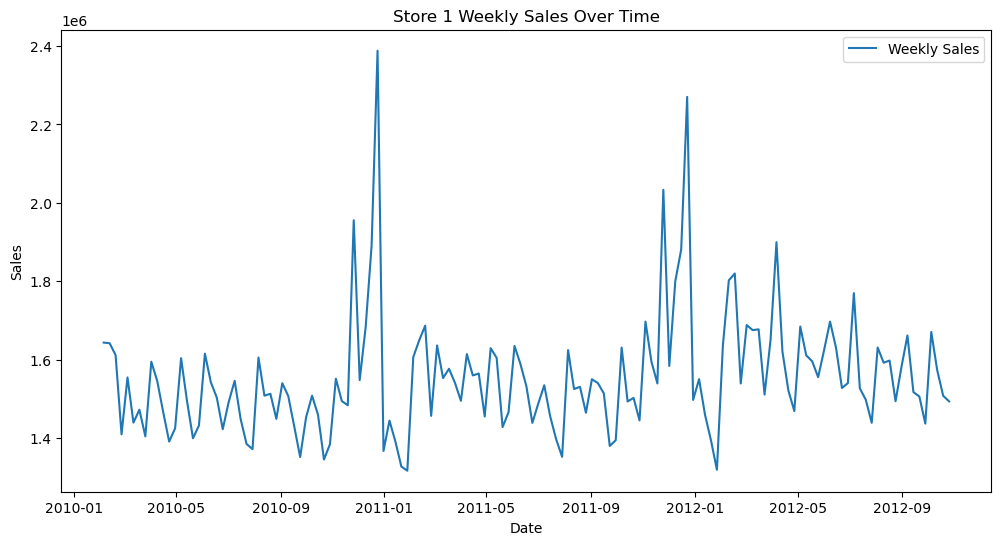

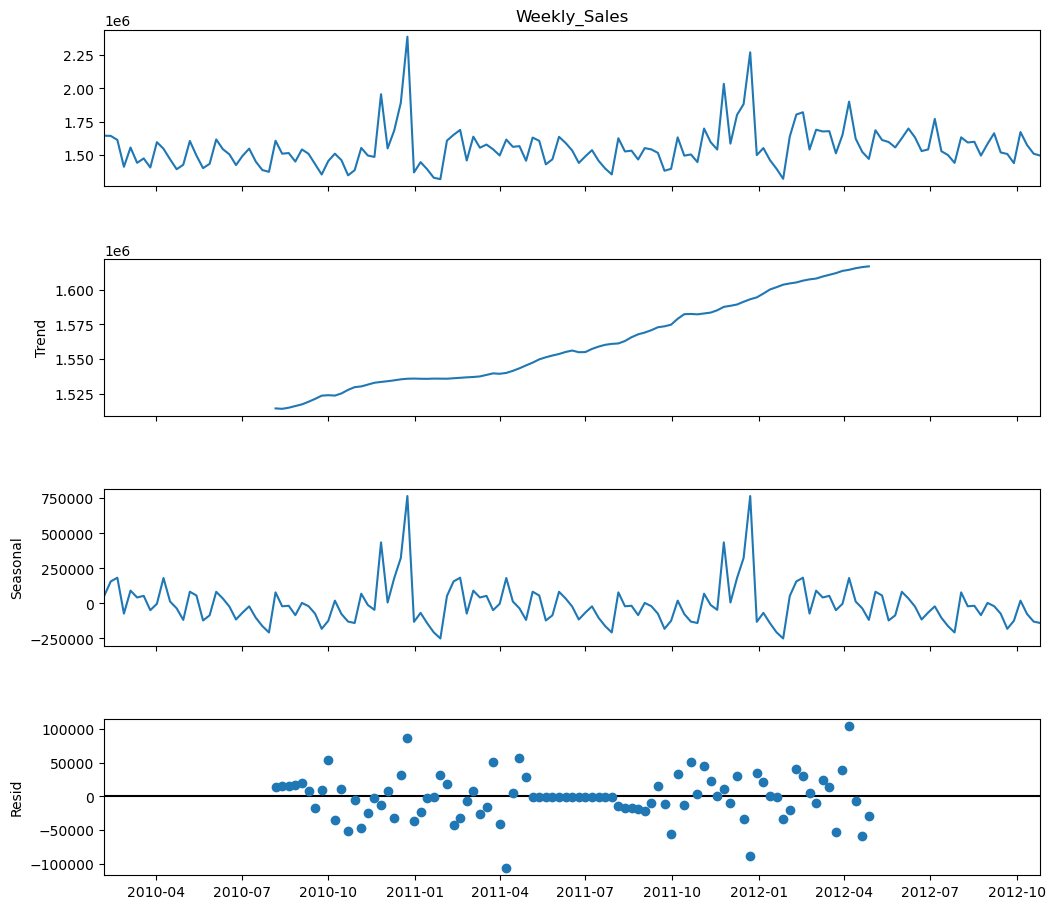

In [8]:
# Plot the raw data
plt.figure(figsize=(12, 6))
plt.plot(ts_data.index, ts_data['Weekly_Sales'], label='Weekly Sales')
plt.title('Store 1 Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

# Decompose the time series to see Trend and Seasonality explicitly
decomposition = seasonal_decompose(ts_data['Weekly_Sales'].fillna(method='ffill'), model='additive')

fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.show()

In [10]:
train_size = int(len(ts_data) * 0.8)
train, test = ts_data[0:train_size], ts_data[train_size:]

print(f"Training Data Size: {len(train)} weeks")
print(f"Testing Data Size: {len(test)} weeks")

Training Data Size: 114 weeks
Testing Data Size: 29 weeks


In [11]:
# Define the ARIMA model
# Order (p,d,q) = (5, 1, 0) is chosen as a starting point for weekly data
# p=5 (lag observations), d=1 (differencing for stationarity), q=0 (moving average)
model = ARIMA(train['Weekly_Sales'], order=(5, 1, 0))

# Fit the model
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                  114
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -1521.258
Date:                Wed, 19 Nov 2025   AIC                           3054.517
Time:                        21:05:08   BIC                           3070.881
Sample:                    02-05-2010   HQIC                          3061.157
                         - 04-06-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2798      0.048     -5.872      0.000      -0.373      -0.186
ar.L2         -0.2524      0.054     -4.645      0.000      -0.359      -0.146
ar.L3         -0.2306      0.071     -3.232      0.0

In [12]:
# Forecast on the test data
forecast_result = model_fit.forecast(steps=len(test))
forecast_series = pd.Series(forecast_result, index=test.index)

# Calculate Evaluation Metrics
# RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(test['Weekly_Sales'], forecast_series))

# MAPE (Mean Absolute Percentage Error)
mape = mean_absolute_percentage_error(test['Weekly_Sales'], forecast_series)

print(f"\n=== Model Evaluation ===")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2%}")
# Note: A MAPE of 0.05 means the model is off by about 5% on average.


=== Model Evaluation ===
Root Mean Squared Error (RMSE): 214981.25
Mean Absolute Percentage Error (MAPE): 13.01%


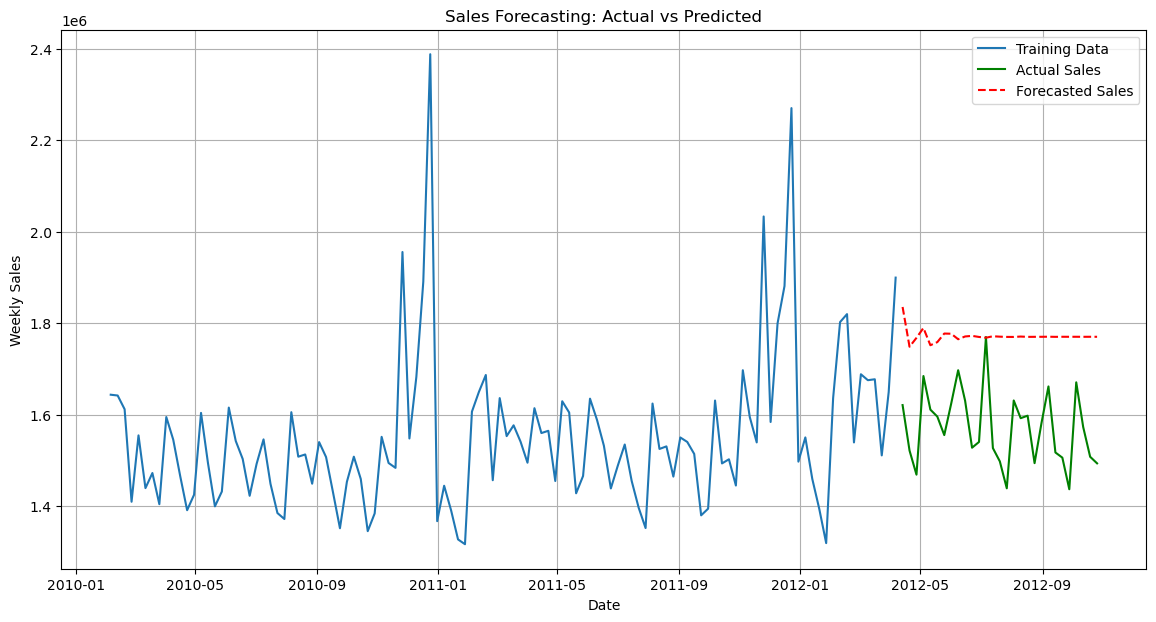

In [13]:
plt.figure(figsize=(14, 7))

# Plot Training Data
plt.plot(train.index, train['Weekly_Sales'], label='Training Data')

# Plot Actual Test Data
plt.plot(test.index, test['Weekly_Sales'], label='Actual Sales', color='green')

# Plot Forecasted Data
plt.plot(test.index, forecast_series, label='Forecasted Sales', color='red', linestyle='--')

plt.title('Sales Forecasting: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True)
plt.show()


In [14]:
pip install tensorflow

   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/332.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/332.0 MB 2.9 MB/s eta 0:01:54
   ---------------------------------------- 1.8/332.0 MB 3.3 MB/s eta 0:01:41
   ---------------------------------------- 2.9/332.0 MB 3.7 MB/s eta 0:01:29
    --------------------------------------- 4.2/332.0 MB 4.2 MB/s eta 0:01:19
    --------------------------------------- 5.5/332.0 MB 4.5 MB/s eta 0:01:13
    --------------------------------------- 7.1/332.0 MB 4.9 MB/s eta 0:01:07
   - -------------------------------------- 8.7/332.0 MB 5.3 MB/s eta 0:01:02
   - -------------------------------------- 10.5/332.0 MB 5.7 MB/s eta 0:00:57
   - -------------------------------------- 12.6/332.0 MB 6.1 MB/s eta 0:00:53
   - -------------------------------------- 14.9/332.0 MB 6.5 MB/s eta 0:00:49
   -- ------------------------------------- 17.0/332.0 MB 6.8 MB/s eta 0:00

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error

In [16]:
# 1. Scale the Data
# We use the same 'ts_data' from the previous steps
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(ts_data['Weekly_Sales'].values.reshape(-1, 1))

# 2. Create Sequences (Sliding Window)
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length]) # Past 'seq_length' weeks
        y.append(data[i+seq_length])   # The next week (target)
    return np.array(X), np.array(y)

# Define sequence length (e.g., look back 60 weeks)
SEQ_LENGTH = 60

# Create X and y
X, y = create_sequences(scaled_data, SEQ_LENGTH)

# Split into Train and Test
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Training Shape: {X_train.shape}")
print(f"Testing Shape: {X_test.shape}")

Training Shape: (66, 60, 1)
Testing Shape: (17, 60, 1)


In [20]:
# Build the Model
model = Sequential()

# LSTM Layer: 50 units, return_sequences=False because we only need the final output
model.add(LSTM(units=50, return_sequences=False, input_shape=(SEQ_LENGTH, 1)))

# Dense Layer: Output 1 value (the predicted sales)
model.add(Dense(1))

# Compile
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 240ms/step - loss: 0.0736 - val_loss: 0.0274
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0446 - val_loss: 0.0104
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0270 - val_loss: 0.0069
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0226 - val_loss: 0.0172
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0265 - val_loss: 0.0185
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0261 - val_loss: 0.0112
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0226 - val_loss: 0.0084
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0210 - val_loss: 0.0075
Epoch 9/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0209 - val_loss: 0.0072
Epoch 10/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0208 - val_loss: 0.0075
Epoch 11/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0208 - val_loss: 0.0076
Epoch 12/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0208 - val_loss: 0.0080


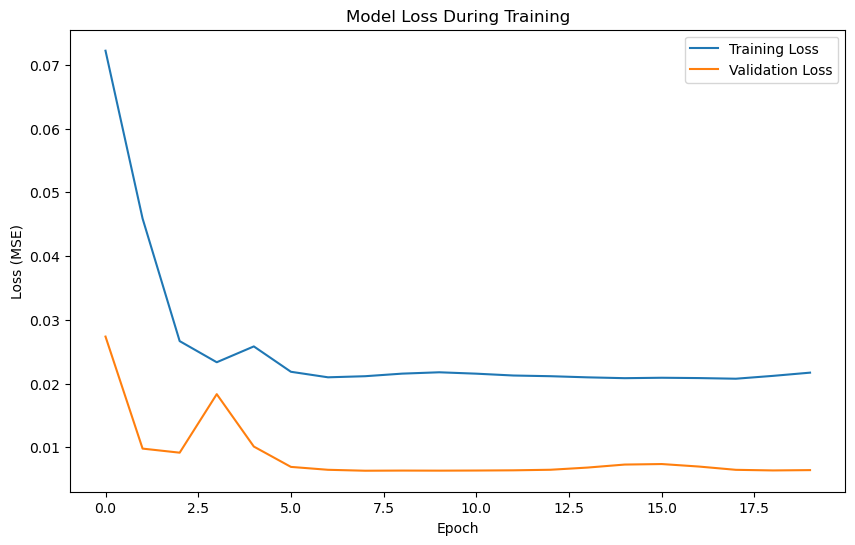

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
LSTM Root Mean Squared Error (RMSE): 85778.90


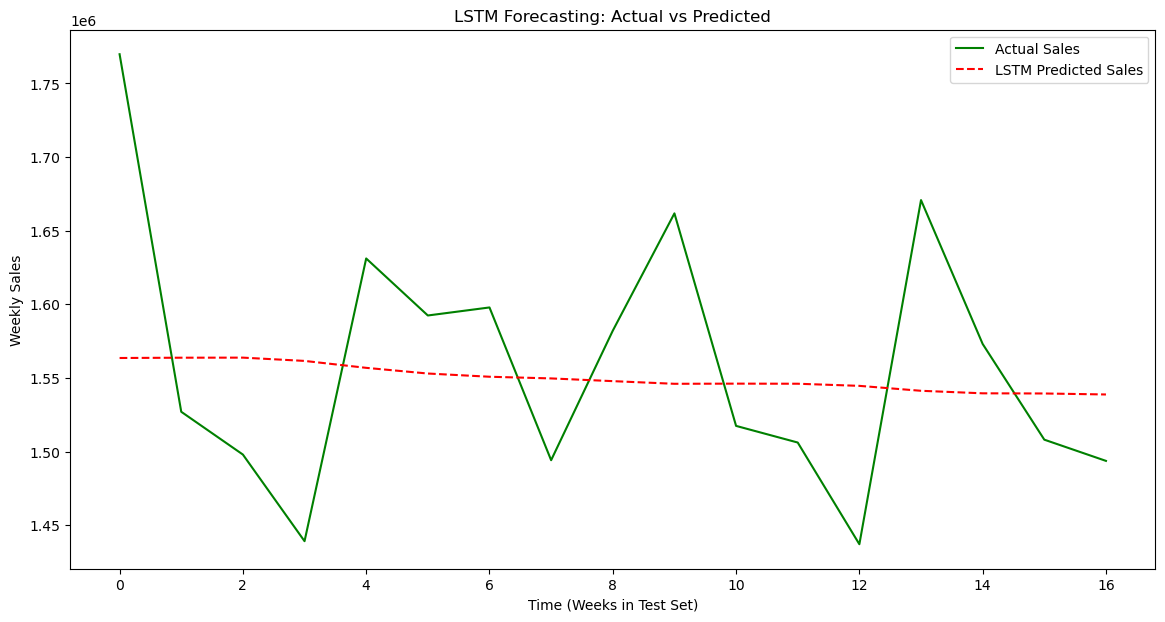

In [19]:
# 1. Make Predictions
lstm_predictions = model.predict(X_test)

# 2. Inverse Transform (Scale back to original values)
lstm_predictions_actual = scaler.inverse_transform(lstm_predictions)
y_test_actual = scaler.inverse_transform(y_test)

# 3. Evaluate (RMSE)
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, lstm_predictions_actual))
print(f"LSTM Root Mean Squared Error (RMSE): {rmse_lstm:.2f}")

# 4. Plot Results
plt.figure(figsize=(14, 7))
plt.plot(y_test_actual, label='Actual Sales', color='green')
plt.plot(lstm_predictions_actual, label='LSTM Predicted Sales', color='red', linestyle='--')
plt.title('LSTM Forecasting: Actual vs Predicted')
plt.xlabel('Time (Weeks in Test Set)')
plt.ylabel('Weekly Sales')
plt.legend()
plt.show()